## Задачи для PyTorch

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchtext
import random
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
import torchtext.data as data
from torchtext.data import Field, LabelField
from torchtext.data import BucketIterator
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc

In [2]:
# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


In [3]:
# Загрузка датасета
df = pd.read_csv('FakeNewsNet.csv')  # Замените на путь к вашему файлу
df = df[['title', 'news_url', 'source_domain', 'real']]

# Проверка на null-значения
print(df.isnull().sum())
df.dropna(inplace=True)

# Проверка баланса классов
print(df['real'].value_counts())

# Комбинирование текстов
df['text'] = df['title'] + ' ' + df['news_url'] + ' ' + df['source_domain']
df = df[['text', 'real']]

title              0
news_url         330
source_domain    330
real               0
dtype: int64
real
1    17371
0     5495
Name: count, dtype: int64


In [4]:
# Определите поля (fields)
TEXT = data.Field(sequential=True, tokenize='spacy', lower=True, tokenizer_language='en_core_web_sm')
LABEL = data.LabelField(dtype=torch.float)

In [5]:
# Создайте список примеров
examples = []
for index, row in df.iterrows():
    text = row['text']
    label = row['real']
    examples.append(data.Example.fromlist([text, label], fields=[('text', TEXT), ('label', LABEL)]))

In [6]:
# Создайте Dataset
dataset = data.Dataset(examples, fields=[('text', TEXT), ('label', LABEL)])

In [7]:
# Задайте seed для воспроизводимости
SEED = 42
random.seed(SEED)

# Разбейте на тренировочный и тестовый наборы данных
train_data, test_data = dataset.split(split_ratio=0.8, random_state=random.seed(SEED))

In [8]:
# Построение словаря
TEXT.build_vocab(train_data)
LABEL.build_vocab(train_data)

In [9]:
# Определение BATCH_SIZE
BATCH_SIZE = 30


In [10]:
# Обучение модели Word2Vec
sentences = [[token for token in sentence] for sentence in dataset.text]

# Обучение модели w2v
w2v_model = Word2Vec(sentences=sentences, vector_size=300, window=5, min_count=1, workers=4)
w2v_model.build_vocab(sentences)
w2v_model.train(sentences, total_examples=len(dataset), epochs=10)
w2v_model.save('w2v_model.txt')

# Загрузка обученной модели
w2v_model = Word2Vec.load('w2v_model.txt')

# Получение word2vec_vectors
word2vec_vectors = w2v_model.wv

# Создание эмбеддинга
pre_trained_emb = torch.FloatTensor(word2vec_vectors.vectors)
#embedding = nn.Embedding.from_pretrained(pre_trained_emb)

In [11]:
# Создаём итератор
train_iterator, test_iterator = BucketIterator.splits(
    (train_data, test_data),
    batch_size=BATCH_SIZE,
    device=device,
    sort_within_batch=True,
    sort_key=lambda x: len(x.text))

In [12]:
class RNN(nn.Module):
    def __init__(self, pre_trained_emb, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super(RNN, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(pre_trained_emb)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers=n_layers, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.embedding(text)
        output, hidden = self.rnn(embedded)
        hidden = hidden[-1, :, :]
        output = self.dropout(hidden)
        output = self.fc(output)

        return output

In [13]:
class LSTM(nn.Module):
    def __init__(self, pre_trained_emb, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(pre_trained_emb)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.lstm(embedded)
        hidden = self.dropout(hidden[-1, :, :])
        return self.fc(hidden)

In [14]:
class GRU(nn.Module):
    def __init__(self, pre_trained_emb, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(pre_trained_emb)
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers=n_layers, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.embedding(text)
        output, hidden = self.gru(embedded)
        hidden = self.dropout(hidden[-1, :, :])
        return self.fc(hidden)

In [15]:
# Вычисляем accuracy
def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

In [16]:
def plot_results(train_losses, train_accuracies, val_losses, val_accuracies, title=''):
    """Отрисовывает графики потерь и точности для обучения."""

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Training Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.suptitle(title) 
    plt.show()

In [17]:
def evaluate_model(model, iterator):
    all_predictions = []
    all_labels = []

    for batch in tqdm(iterator):
        predictions = model(batch.text).squeeze(1)
        all_predictions += predictions.tolist()
        all_labels += batch.label.tolist()

    all_predictions = torch.tensor(all_predictions)
    all_labels = torch.tensor(all_labels)

    y_pred_binary = torch.round(torch.sigmoid(all_predictions)).cpu().numpy()
    y_true = all_labels.cpu().numpy()

    accuracy = accuracy_score(y_true, y_pred_binary)
    f1 = f1_score(y_true, y_pred_binary)
    roc_auc = roc_auc_score(y_true, all_predictions.cpu().numpy())

    fpr, tpr, _ = roc_curve(y_true, all_predictions.cpu().numpy())
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    print("Accuracy:", accuracy)
    print("F1 Score:", f1)
    print("ROC AUC Score:", roc_auc)

In [18]:
def train_model(model, train_iterator, optimizer, criterion, epochs):
    """Обучает модель RNN, LSTM или GRU."""

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in tqdm(range(epochs)):
        epoch_loss = 0
        epoch_acc = 0
        model.train()

        all_predictions = []
        all_labels = []

        for batch in train_iterator:
            optimizer.zero_grad()
            predictions = model(batch.text).squeeze()
            # Проверка и исправление размера batch.label
            if len(batch.label.size()) == 2:  # Если размер 2, то сжимаем
                batch.label = batch.label.squeeze() 
            elif batch.label.size()[0] != predictions.size()[0]: # Если первое измерение не совпадает, то переформатируем
                batch.label = batch.label.view(-1) 
    
            loss = criterion(predictions, batch.label)
            acc = binary_accuracy(predictions, batch.label)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

            all_predictions += predictions.tolist()
            all_labels += batch.label.tolist()
            
        all_predictions = torch.tensor(all_predictions)
        all_labels = torch.tensor(all_labels)
        val_acc = binary_accuracy(all_predictions, all_labels)
        val_loss = criterion(all_predictions, all_labels).item()

        train_losses.append(epoch_loss / len(train_iterator))
        train_accuracies.append(epoch_acc / len(train_iterator))
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f'Epoch: {epoch+1:02}, Train Loss: {train_losses[-1]:.3f}, Train Acc: {train_accuracies[-1]*100:.2f}%, Val Loss: {val_losses[-1]:.3f}, Val Acc: {val_accuracies[-1]*100:.2f}%')

    return train_losses, train_accuracies, val_losses, val_accuracies

In [19]:
def train_and_plot(model_class, model_name, pre_trained_emb, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT, train_iterator, test_iterator, n_epochs):
    """Обучает модель и строит графики результатов."""
    model = model_class(pre_trained_emb, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)

    optimizer = optim.Adam(model.parameters())
    criterion = nn.BCEWithLogitsLoss()
    model = model.to(device)
    criterion = criterion.to(device)
    train_losses, train_accuracies, val_losses, val_accuracies = train_model(model, train_iterator, optimizer, criterion, n_epochs)
    plot_results(train_losses, train_accuracies, val_losses, val_accuracies, title=f'{model_name} Training Results')
    evaluate_model(model, test_iterator) 

In [20]:
# Определение констант для модели
EMBEDDING_DIM = 300  # Размерность эмбеддинга (из word2vec)
HIDDEN_DIM = 128    # Размерность скрытого состояния RNN
OUTPUT_DIM = 1      # Размерность выходного слоя (1 для бинарной классификации)
N_LAYERS = 2        # Количество слоев в RNN
DROPOUT = 0.5      # Вероятность дропаута

In [21]:
N_EPOCHS = 19

  5%|██▎                                        | 1/19 [00:03<01:02,  3.49s/it]

Epoch: 01, Train Loss: 0.519, Train Acc: 77.74%, Val Loss: 0.519, Val Acc: 77.75%


 11%|████▌                                      | 2/19 [00:06<00:52,  3.06s/it]

Epoch: 02, Train Loss: 0.491, Train Acc: 79.55%, Val Loss: 0.491, Val Acc: 79.55%


 16%|██████▊                                    | 3/19 [00:09<00:47,  2.97s/it]

...

Epoch: 17, Train Loss: 0.370, Train Acc: 85.50%, Val Loss: 0.370, Val Acc: 85.50%


 95%|███████████████████████████████████████▊  | 18/19 [00:59<00:03,  3.26s/it]

Epoch: 18, Train Loss: 0.364, Train Acc: 85.78%, Val Loss: 0.364, Val Acc: 85.79%


100%|██████████████████████████████████████████| 19/19 [01:02<00:00,  3.30s/it]

Epoch: 19, Train Loss: 0.351, Train Acc: 86.39%, Val Loss: 0.351, Val Acc: 86.39%


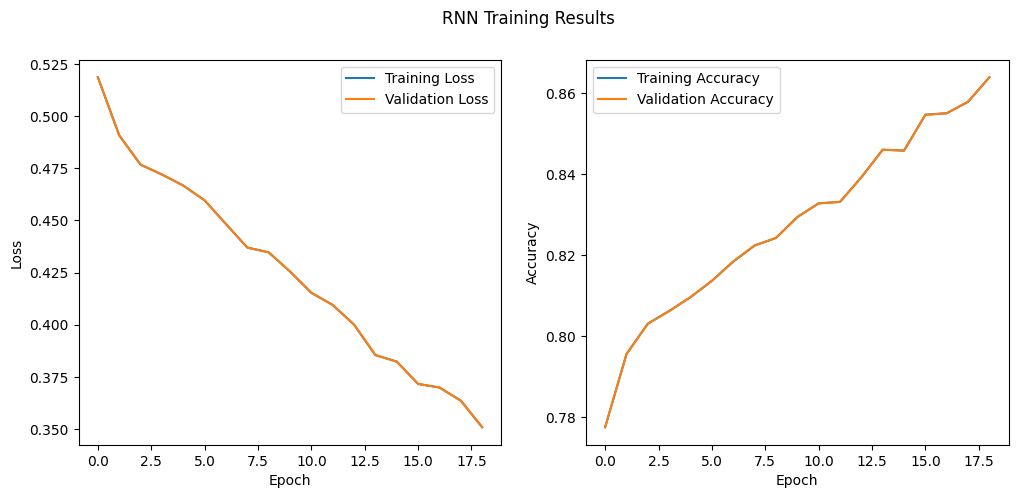

100%|███████████████████████████████████████| 153/153 [00:00<00:00, 361.91it/s]


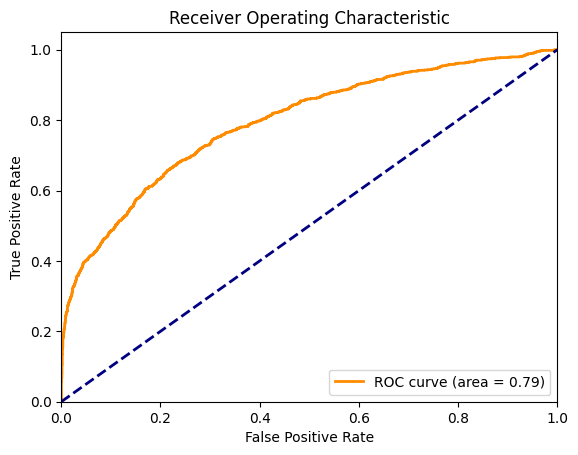

Accuracy: 0.8007872293898972
F1 Score: 0.5349668198060235
ROC AUC Score: 0.7933502461494659


In [22]:
# Обучаем модели и строим графики
train_and_plot(RNN, 'RNN', pre_trained_emb, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT, train_iterator, test_iterator, N_EPOCHS)


  5%|██▎                                        | 1/19 [00:04<01:15,  4.20s/it]

Epoch: 01, Train Loss: 0.481, Train Acc: 79.22%, Val Loss: 0.481, Val Acc: 79.22%


 11%|████▌                                      | 2/19 [00:08<01:14,  4.38s/it]

Epoch: 02, Train Loss: 0.406, Train Acc: 83.29%, Val Loss: 0.406, Val Acc: 83.29%


 16%|██████▊                                    | 3/19 [00:12<01:06,  4.14s/it]

...

Epoch: 17, Train Loss: 0.092, Train Acc: 96.39%, Val Loss: 0.092, Val Acc: 96.39%


 95%|███████████████████████████████████████▊  | 18/19 [01:13<00:04,  4.28s/it]

Epoch: 18, Train Loss: 0.082, Train Acc: 96.98%, Val Loss: 0.082, Val Acc: 96.98%


100%|██████████████████████████████████████████| 19/19 [01:17<00:00,  4.10s/it]

Epoch: 19, Train Loss: 0.092, Train Acc: 96.50%, Val Loss: 0.092, Val Acc: 96.50%


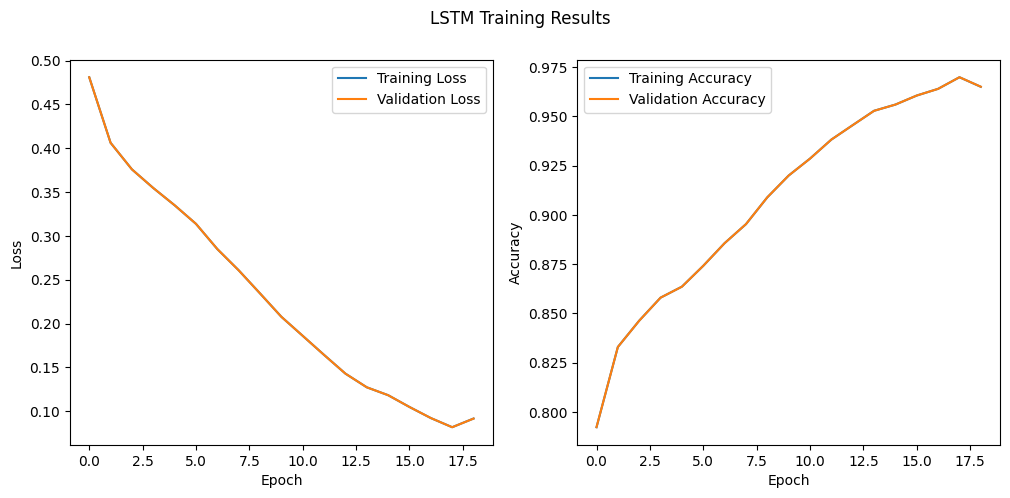

100%|███████████████████████████████████████| 153/153 [00:00<00:00, 336.46it/s]


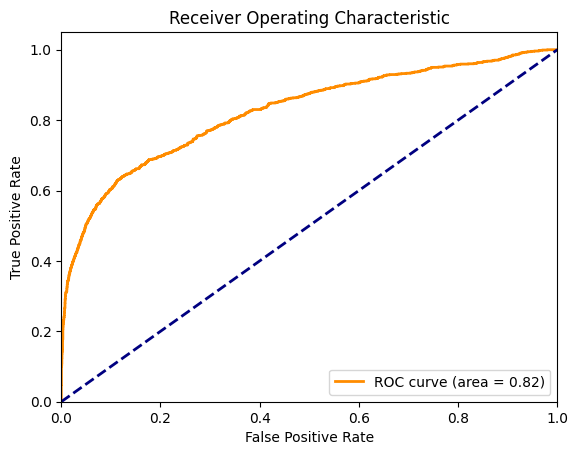

Accuracy: 0.8421167723595014
F1 Score: 0.5737898465171193
ROC AUC Score: 0.8240376586373286


In [23]:
train_and_plot(LSTM, 'LSTM', pre_trained_emb, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT, train_iterator, test_iterator, N_EPOCHS)

  5%|██▎                                        | 1/19 [00:03<00:55,  3.09s/it]

Epoch: 01, Train Loss: 0.471, Train Acc: 79.91%, Val Loss: 0.471, Val Acc: 79.90%


 11%|████▌                                      | 2/19 [00:06<00:52,  3.10s/it]

Epoch: 02, Train Loss: 0.404, Train Acc: 83.35%, Val Loss: 0.404, Val Acc: 83.35%


 16%|██████▊                                    | 3/19 [00:09<00:49,  3.11s/it]

...

Epoch: 17, Train Loss: 0.096, Train Acc: 96.42%, Val Loss: 0.096, Val Acc: 96.42%


 95%|███████████████████████████████████████▊  | 18/19 [00:58<00:02,  2.97s/it]

Epoch: 18, Train Loss: 0.084, Train Acc: 96.99%, Val Loss: 0.084, Val Acc: 96.99%


100%|██████████████████████████████████████████| 19/19 [01:01<00:00,  3.24s/it]

Epoch: 19, Train Loss: 0.083, Train Acc: 96.90%, Val Loss: 0.083, Val Acc: 96.90%


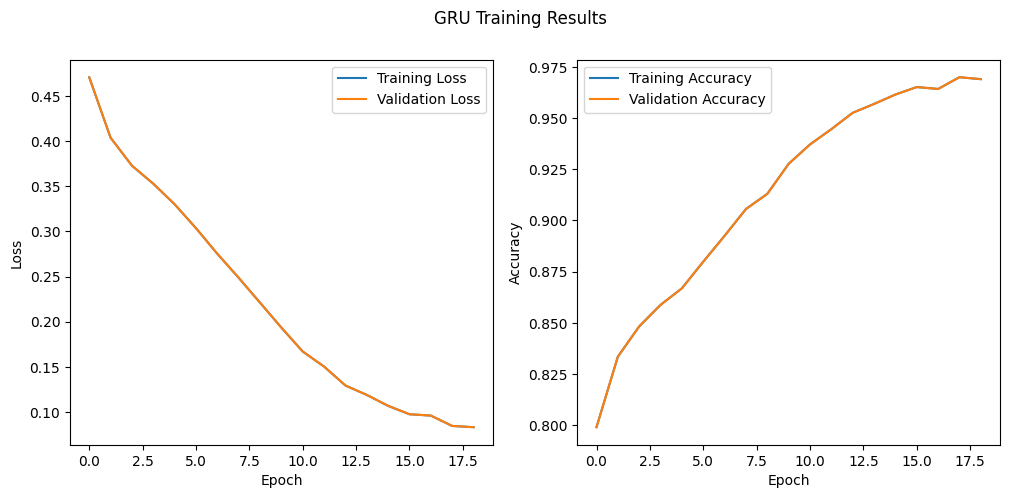

100%|███████████████████████████████████████| 153/153 [00:00<00:00, 550.68it/s]


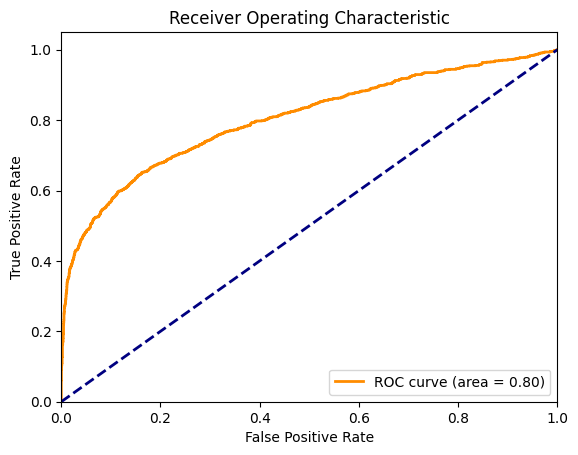

Accuracy: 0.8399300240542313
F1 Score: 0.5313700384122919
ROC AUC Score: 0.8026954535120653


In [24]:
train_and_plot(GRU, 'GRU', pre_trained_emb, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT, train_iterator, test_iterator, N_EPOCHS)

## Задачи для TensorFlow

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


title              0
news_url         330
source_domain    330
real               0
dtype: int64
real
1    17371
0     5495
Name: count, dtype: int64
text    0
real    0
dtype: int64


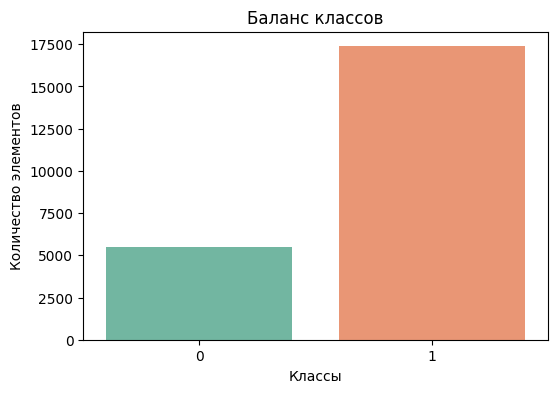

In [25]:
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import torch
from gensim.models import Word2Vec
from tensorflow.keras.layers import TextVectorization, LayerNormalization, Dropout, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import  accuracy_score, f1_score, roc_auc_score, roc_curve, auc
import numpy as np

import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.initializers import Constant

import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet') 

stop_words = set(stopwords.words('english'))

df = pd.read_csv('FakeNewsNet.csv')
df = df[['title', 'news_url', 'source_domain', 'real']]

# Проверка наличия пропущенных значений и удаление строк с пропущенными значениями
print(df.isnull().sum())
df.dropna(inplace=True)

print(df['real'].value_counts())

# Объединяем title, news_url и source_domain в один текстовый столбец
df['text'] = df['title'] + ' ' + df['news_url'] + ' ' + df['source_domain']
df = df[['text', 'real']]

# После объединения столбцов еще раз проверка пропущенных значений
print(df.isnull().sum())

# Количество элементов каждого класса
class_counts = df['real'].value_counts()

# Визуализация графика баланса классов
plt.figure(figsize=(6, 4))
sns.countplot(x='real', data=df, hue='real', palette='Set2', legend=False)
plt.title('Баланс классов')
plt.xlabel('Классы')
plt.ylabel('Количество элементов')
plt.show()

In [39]:
def preprocess_text(text):
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.lower() not in stop_words]
    tokens = [word for word in tokens if word.isalpha()]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    preprocessed_text = ' '.join(tokens)
    return preprocessed_text

def preprocess_dataframe(dataframe, text_column):
    dataframe[text_column] = dataframe[text_column].apply(preprocess_text)
    return dataframe

def create_model(model_type):

  if model_type == 'RNN':
    model_layer = tf.keras.layers.RNN(tf.keras.layers.SimpleRNNCell(HIDDEN_DIM)) 
  elif model_type == 'LSTM':
    model_layer = tf.keras.layers.LSTM(HIDDEN_DIM)  
  elif model_type == 'GRU':
    model_layer = tf.keras.layers.GRU(HIDDEN_DIM)  
  else:
    raise ValueError(f"Unknown model type: {model_type}")

  model = tf.keras.Sequential([
      embedding_layer,
      model_layer,
      tf.keras.layers.Flatten(),
      tf.keras.layers.Dropout(0.2),
      LayerNormalization(), 
      Dense(OUTPUT_DIM, activation='sigmoid')
  ])
  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
  return model 

# Определяем функцию для обучения модели и выведите на график результаты обучения
def train_and_plot(model_type, train_dataset, test_dataset, BATCH):
    print(model_type)
    model = create_model(model_type)
      
    # Используем early_stop, который прекращает обучение, когда validation loss больше не улучшается
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    
    # Обучение модели
    history = model.fit(X_train, y_train, epochs=N_EPOCHS, validation_split=0.2, batch_size=BATCH, shuffle=True, callbacks=[early_stop])

    results = model.evaluate(test_dataset)
    print(f'{model_type} - Test Loss: {results[0]}, Test Accuracy: {results[1]}')

    history_dict = history.history
    
    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    epochs = history.epoch
    
    plt.figure(figsize=(6,4))
    plt.plot(epochs, loss, 'r', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss', size=10)
    plt.xlabel('Epochs', size=10)
    plt.ylabel('Loss', size=10)
    plt.legend(prop={'size': 10})
    plt.show()
    
    plt.figure(figsize=(6,4))
    plt.plot(epochs, acc, 'g', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy', size=10)
    plt.xlabel('Epochs', size=10)
    plt.ylabel('Accuracy', size=10)
    plt.legend(prop={'size': 10})
    plt.ylim((0.5,1))
    plt.show()

    # Оценка производительности модели
    y_pred = model.predict(X_test)

    # Преобразуем y_pred в бинарные значения (0 или 1)
    y_pred_binary = np.round(y_pred).astype(int) 
    y_pred_binary = np.array(y_pred_binary).flatten()

    accuracy = accuracy_score(y_test, y_pred_binary) 
    f1 = f1_score(y_test, y_pred_binary) 
    roc_auc = roc_auc_score(y_test, y_pred)
    

    # Строим ROC-кривую
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
       
    print(f'{model_type} - Test Accuracy: {accuracy}, F1-Score: {f1}, AUC-ROC: {roc_auc}')
 

In [43]:
# Предварительная обработка текстовых данных
df = preprocess_dataframe(df, 'text')

# Определение гиперпараметров
EMBEDDING_DIM = 300
HIDDEN_DIM = 256   
OUTPUT_DIM = 1
N_EPOCHS = 20
BATCH = 8

# Разделение текста на предложения
sentences = df['text'].apply(lambda x: x.split())

RNN
Epoch 1/20
1830/1830 [==============================] - 32s 17ms/step - loss: 0.4484 - accuracy: 0.8140 - val_loss: 0.3975 - val_accuracy: 0.8281
Epoch 2/20
1830/1830 [==============================] - 33s 18ms/step - loss: 0.3875 - accuracy: 0.8431 - val_loss: 0.3848 - val_accuracy: 0.8502
Epoch 3/20
1830/1830 [==============================] - 34s 19ms/step - loss: 0.3805 - accuracy: 0.8427 - val_loss: 0.3971 - val_accuracy: 0.8352
Epoch 4/20
1830/1830 [==============================] - 35s 19ms/step - loss: 0.3742 - accuracy: 0.8455 - val_loss: 0.3744 - val_accuracy: 0.8450
Epoch 5/20
1830/1830 [==============================] - 36s 20ms/step - loss: 0.3741 - accuracy: 0.8471 - val_loss: 0.5450 - val_accuracy: 0.8106
Epoch 6/20
1830/1830 [==============================] - 37s 20ms/step - loss: 0.3589 - accuracy: 0.8499 - val_loss: 0.3715 - val_accuracy: 0.8530
Epoch 7/20
1830/1830 [==============================] - 38s 21ms/step - loss: 0.3741 - accuracy: 0.8445 - val_loss: 0.36

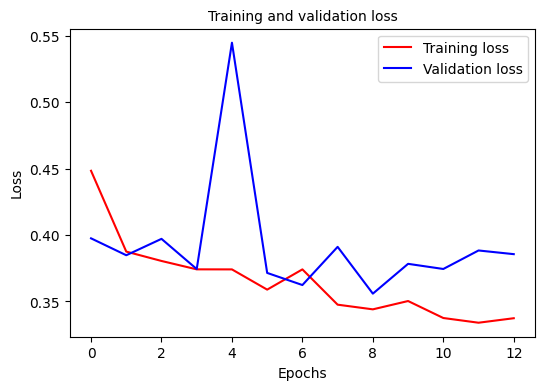

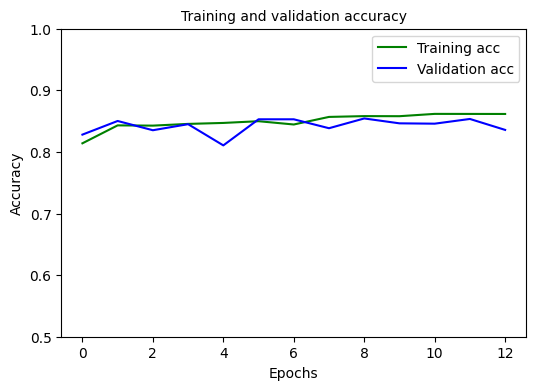

143/143 [==============================] - 3s 19ms/step


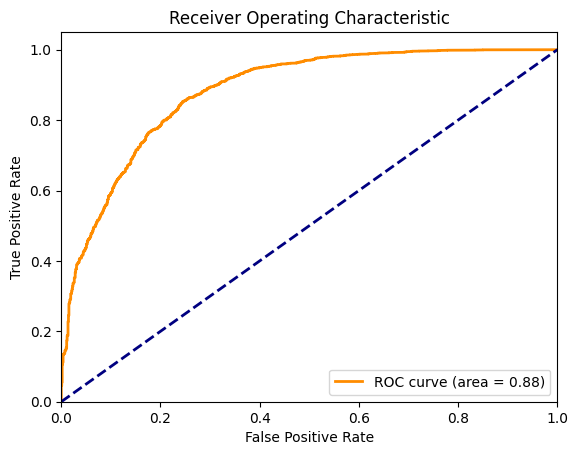

RNN - Test Accuracy: 0.865107127240927, F1-Score: 0.913934997907658, AUC-ROC: 0.8810480415418268
LSTM
Epoch 1/20
1830/1830 [==============================] - 96s 51ms/step - loss: 0.3867 - accuracy: 0.8420 - val_loss: 0.3487 - val_accuracy: 0.8557
Epoch 2/20
1830/1830 [==============================] - 103s 56ms/step - loss: 0.3224 - accuracy: 0.8669 - val_loss: 0.4037 - val_accuracy: 0.8579
Epoch 3/20
1830/1830 [==============================] - 104s 57ms/step - loss: 0.2846 - accuracy: 0.8825 - val_loss: 0.3562 - val_accuracy: 0.8565
Epoch 4/20
1830/1830 [==============================] - 105s 57ms/step - loss: 0.2343 - accuracy: 0.9021 - val_loss: 0.3695 - val_accuracy: 0.8636
Epoch 5/20
572/572 [==============================] - 9s 15ms/step - loss: 0.3424 - accuracy: 0.8566
LSTM - Test Loss: 0.34235724806785583, Test Accuracy: 0.8565705418586731


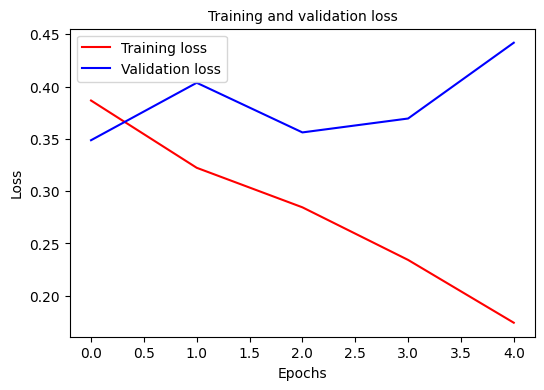

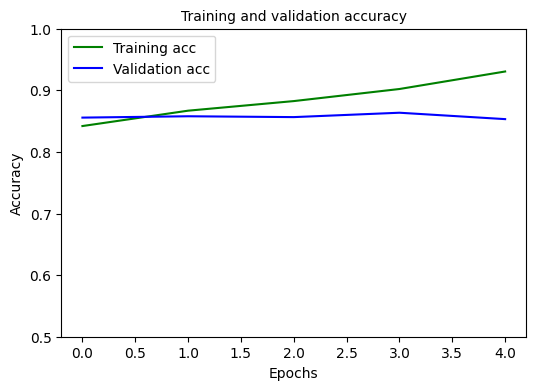

143/143 [==============================] - 6s 39ms/step


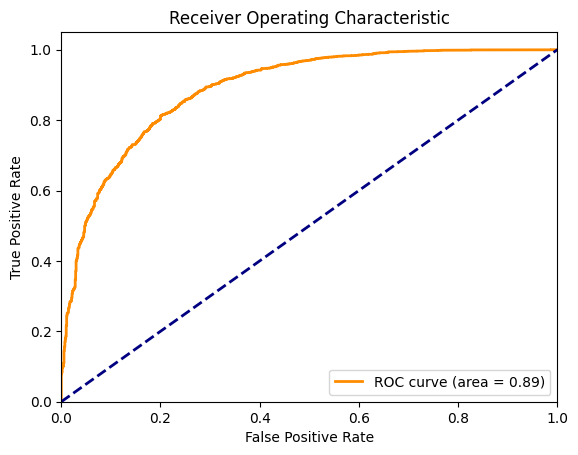

LSTM - Test Accuracy: 0.8565806733712287, F1-Score: 0.9072660446706248, AUC-ROC: 0.8887516973217209
GRU
Epoch 1/20
1830/1830 [==============================] - 77s 41ms/step - loss: 0.3886 - accuracy: 0.8427 - val_loss: 0.3586 - val_accuracy: 0.8546
Epoch 2/20
1830/1830 [==============================] - 80s 44ms/step - loss: 0.3328 - accuracy: 0.8622 - val_loss: 0.3729 - val_accuracy: 0.8475
Epoch 3/20
1830/1830 [==============================] - 80s 44ms/step - loss: 0.3043 - accuracy: 0.8752 - val_loss: 0.3491 - val_accuracy: 0.8625
Epoch 4/20
1830/1830 [==============================] - 81s 44ms/step - loss: 0.2672 - accuracy: 0.8907 - val_loss: 0.3702 - val_accuracy: 0.8606
Epoch 5/20
1830/1830 [==============================] - 81s 44ms/step - loss: 0.2218 - accuracy: 0.9107 - val_loss: 0.3729 - val_accuracy: 0.8598
Epoch 6/20
1830/1830 [==============================] - 82s 45ms/step - loss: 0.1569 - accuracy: 0.9378 - val_loss: 0.4523 - val_accuracy: 0.8513
Epoch 7/20
572/572 [

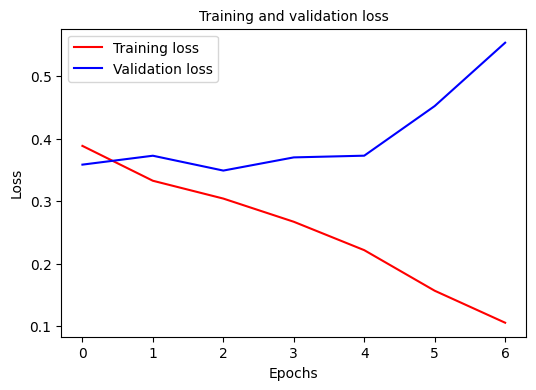

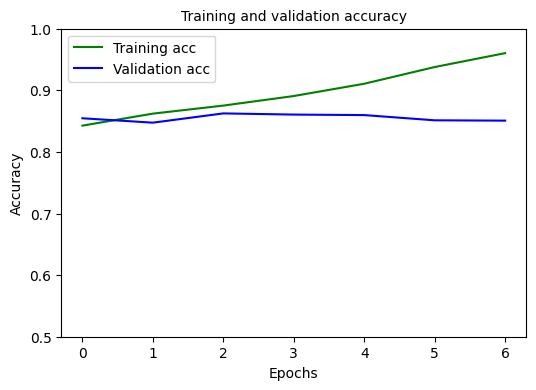

143/143 [==============================] - 7s 41ms/step


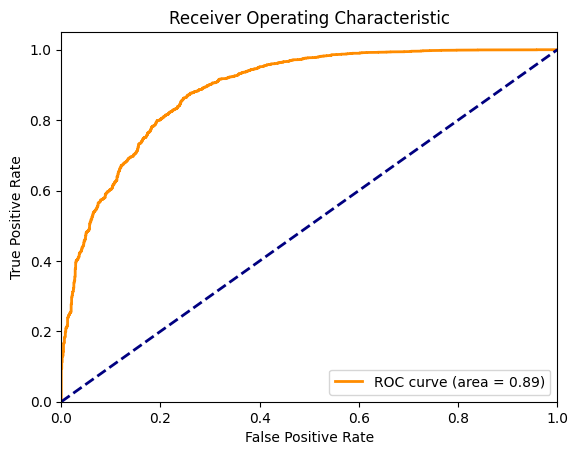

GRU - Test Accuracy: 0.8664188893747267, F1-Score: 0.9154793194079403, AUC-ROC: 0.8871786175942316


In [46]:
w2v_model = Word2Vec(
                        sentences=sentences, 
                        vector_size=EMBEDDING_DIM, 
                        window=10, 
                        min_count=1, 
                        workers=8, 
                        negative=10,
                        alpha=0.04,
                        min_alpha=0.0007,
                        sample=6e-5,
                        sg=1, 
                        hs=1,
                        seed=42
                    )

w2v_model.build_vocab(sentences)  # Создание словаря модели
w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=15)  # Обучение модели на предложениях
w2v_model.save('w2v_model.txt')  # Сохранение обученной модели

# Загрузка обученной модели Word2Vec
w2v_model = Word2Vec.load('w2v_model.txt')

# Получение вложений слов
word2vec_vectors = w2v_model.wv

# Преобразование вложений слов в тензор TensorFlow
pre_trained_emb = tf.convert_to_tensor(word2vec_vectors.vectors, dtype=tf.float32)

# Добавление строки заполнения
padding_row = tf.zeros([1, EMBEDDING_DIM], dtype=tf.float32) 
pre_trained_emb = tf.concat([pre_trained_emb, padding_row], axis=0)

INPUT_DIM = len(word2vec_vectors.key_to_index) + 1

# Определение максимального размера словаря
max_size = len(w2v_model.wv.key_to_index)

# Создает словарь из num_words наиболее часто встречающихся слов в тексте.
tokenizer = Tokenizer(num_words=max_size)  # Используем max_size, чтобы сохранить все слова из Word2Vec
tokenizer.fit_on_texts(df['text'])

# Преобразует текст в последовательности целых чисел (индексы слов в словаре).
tokenized_text = tokenizer.texts_to_sequences(df['text'])

# Выравнивание последовательностей по длине (паддинг), для передачи в модель
maxlen = max(len(x) for x in tokenized_text)
padded_text = pad_sequences(tokenized_text, maxlen=maxlen)

# Создание Embedding-слоя
embedding_matrix = np.zeros((len(tokenizer.word_index) + 1, w2v_model.vector_size))  # Размер соответствует словарю Tokenizer

# Итерация по словарю "слово: индекс"
for word, i in tokenizer.word_index.items():
    # Если индекс превышает кол-во слов в словаре, то скипаем
    if i > tokenizer.num_words:
        continue
    # Проверяем, существует ли слово в словаре w2v_model.wv
    if word in w2v_model.wv:
        # Получаем вектор соответствущий слову в модели word2vec
        embedding_vector = w2v_model.wv[word]
        # Если слово найдено в словаре токенизатора, то в embedding_matrix проставляем вектор соответствующий слову
        embedding_matrix[i] = embedding_vector
    else:
        # Если слово не найдено, то можно использовать нулевой вектор
        embedding_matrix[i] = np.zeros(w2v_model.vector_size) 


# Embedding слой
embedding_layer = Embedding(
    # Размер словаря
    input_dim = len(tokenizer.word_index) + 1,  # Используем размер словаря Tokenizer
    # Размер вектора вложений
    output_dim = w2v_model.vector_size,
    # Установка весов слоя
    embeddings_initializer = Constant(embedding_matrix),
    # Длина входных последовательностей
    input_length = maxlen,
    # Предотвратит обновление весов во время обучения
    trainable = False
    )

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(padded_text, df['real'], test_size=0.20, random_state=42) 

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH)

for model_type in ['RNN', 'LSTM', 'GRU']:
    train_and_plot(model_type, train_dataset, test_dataset, BATCH)

